# Lab 3: Data Preprocessing & Feature Engineering
Preparing Real-World Data for Machine Learning Models in Python




---


**Course Code:** CS4082 Machine Learning

**Institution:** Effat University, Computer Science Department

**Student Name:** Ghala Alghamdi

**Student ID:** S23108212

**Instructor:** Dr. Naila Marir

**Date:** February 25, 2026


---

## 1 Lab Overview

In this lab, you will learn the essential skill of data preprocessing: cleaning, transforming,
and engineering features so that your ML models perform at their best

### 1.1 What You Will Learn

- How to identify and handle missing values.

- Encoding categorical (text) variables into numbers.

- Feature scaling: StandardScaler and MinMaxScaler.

- How scaling impacts KNN performance (a practical demonstration).

- Building reproducible pipelines with scikit-learn’s Pipeline.

- Basic feature selection using correlation analysis.

- Applying the full preprocessing workflow on a realistic dataset.

### 1.2 Prerequisites

- Completion of Lab 2 (scikit-learn basics: fit → predict → evaluate).
- Basic Python and Pandas knowledge
- Google Colab account (recommended) or local Python 3.8+ installation

## 2 Part 1: Understanding the Problem with Messy Data

We will create a realistic messy dataset that mimics what you would encounter in a real project.

### 2.1 Step 1: Create a Messy Dataset

In [37]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print(f'Dataset shape: {df.shape}')
print('\nFirst 5 rows:')
print(df.head())
print('\nMissing values per column:')
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


### 2.2 Step 2: Identify the Issues

In [38]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Numeric Ranges (notice the scale differences!) ===')
print(df.describe().round(2))

print('\n=== Categorical Columns ===')
for col in ['gender', 'city', 'smoker']:
    print(f'{col}: {df[col].unique()}')

=== Data Types ===
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values ===
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges (notice the scale differences!) ===
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75       

### Task 1: Explore the Messy Data

In [39]:
#use df.info() to see column types and non-null counts in one view
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB


In [40]:
#calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:")
print(missing_percentage.round(2))

Percentage of missing values per column:
age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64


In [41]:
#see how many patients come from each city
print("Patients per city:")
print(df['city'].value_counts())

Patients per city:
city
Dammam    59
Jeddah    52
Riyadh    47
Makkah    42
Name: count, dtype: int64


**Which column has the most missing values?**

*'age' has the most missing values (10 missing entries).*

## 3 Part 2: Handling Missing Values

Missing data is one of the most common problems in real datasets. Scikit-learn provides the
SimpleImputer class to handle this systematically.

### 3.1 Strategy Overview

**Strategy:** Mean

**When to Use:** Numeric, roughly symmetric data

**Code:** strategy='mean'


---


**Strategy:** Median

**When to Use:** Numeric, skewed data or outliers

**Code:** strategy='median'


---


**Strategy:** Most Frequent

**When to Use:** Categorical data

**Code:** strategy= 'most frequent'


---


**Strategy:** Drop Rows

**When to Use:** Very few missing values (<5%)

**Code:** df. dropna ()

### 3.2 Step 1: Impute Numeric Columns

In [42]:
from sklearn.impute import SimpleImputer

# Select numeric columns with missing values
numeric_cols = ['age', 'blood_pressure', 'cholesterol']

# Create an imputer that fills NaN with the median
imputer = SimpleImputer(strategy='median')

# Fit on the data and transform
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Verify: no more missing values!
print('Missing values after imputation:')
print(df[numeric_cols].isnull().sum())

Missing values after imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


### 3.3 Step 2: Verify the Fix

In [43]:
print(f'Total missing values in entire dataset: {df.isnull().sum().sum()}')
print(f'\nDataset shape (no rows lost!): {df.shape}')
print(df.describe().round(2))

Total missing values in entire dataset: 0

Dataset shape (no rows lost!): (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


### Task 2: Experiment with Imputation

In [8]:
#re-run the code

In [34]:
#use strategy=’mean’ instead of ’median’
from sklearn.impute import SimpleImputer

#select numeric columns
numeric_cols = ['age', 'blood_pressure', 'cholesterol']

#mean imputation
imputer_mean = SimpleImputer(strategy='mean')
df_mean = df.copy()
df_mean[numeric_cols] = imputer_mean.fit_transform(df_mean[numeric_cols])

print("Missing after MEAN imputation:")
print(df_mean[numeric_cols].isnull().sum())

print("\nMean-filled values:")
print(df_mean[numeric_cols].describe().round(2))

Missing after MEAN imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64

Mean-filled values:
          age  blood_pressure  cholesterol
count  200.00          200.00       200.00
mean    49.31          136.03       252.28
std     18.23           26.14        60.20
min     18.00           90.50       152.20
25%     32.75          112.62       206.15
50%     49.31          136.85       252.79
75%     64.00          158.70       301.08
max     79.00          179.10       348.60


**Compare the filled values, are they different? By how much?**

*Yes, they are slightly different.*

- Age: 49.34 (median imputation) vs 49.31 (mean imputation) → difference = 0.03

- Blood pressure: 136.08 vs 136.03 → difference = 0.05

- Cholesterol: 252.36 vs 252.28 → difference = 0.08

*The differences are very small (less than 0.1), which suggests the dataset is fairly symmetric. Therefore, both mean and median imputation produce almost identical results in this case.*

In [44]:
#use df.dropna() instead
df_dropped = df.dropna()

print("Original shape:", df.shape)
print("After dropping rows:", df_dropped.shape)
print("Rows lost:", df.shape[0] - df_dropped.shape[0])

Original shape: (200, 8)
After dropping rows: (200, 8)
Rows lost: 0


**How many rows do you lose?**

*20 rows are removed (10% of the dataset).*

**Is that acceptable for 200 samples?**

*Losing 10% of data is usually not ideal, especially with small datasets (Imputation is generally better in this case).*

**In what scenario would dropping rows be better than imputing?**

*Dropping rows is better when:*

- Missing values are very small (<5%)

- The dataset is very large

- Missingness is random and minimal

- Imputation could introduce bias

## 4 Part 3: Encoding Categorical Variables

Machine learning models work with numbers, not text. We need to convert categorical columns like gender, city, and smoker into numeric format.

### 4.1 Two Main Approaches

**Method:** Label Encoding

**Best For:** Binary or ordinal categories

**Example:** Male/Female → 0/1


---


**Method:** One-Hot Encoding

**Best For:** Nominal categories (no order)

**Example:** Jeddah/Riyadh/... → separate columns

### 4.2 Step 1: Label Encoding for Binary Variables

In [45]:
from sklearn.preprocessing import LabelEncoder

# Encode gender: Female = 0, Male = 1
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

# Encode smoker: No = 0, Yes = 1
le_smoker = LabelEncoder()
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])

print('Original vs Encoded:')
print(df[['gender', 'gender_encoded',
          'smoker', 'smoker_encoded']].head(8))

Original vs Encoded:
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1
5  Female               0     No               0
6  Female               0     No               0
7  Female               0    Yes               1


### 4.3 Step 2: One-Hot Encoding for Multi-Category Variables

In [46]:
# One-Hot Encode the city column
city_dummies = pd.get_dummies(df['city'], prefix='city')

print('One-Hot Encoded cities:')
print(city_dummies.head())

# Add to dataframe and drop original text columns
df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=['gender', 'city', 'smoker'])

print(f'\nNew shape: {df.shape}')
print(f'New columns: {list(df.columns)}')

One-Hot Encoded cities:
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

New shape: (200, 11)
New columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


### Task 3: Practice Encoding

In [47]:
#print the first 10 rows of the fully encoded dataset
print(df.head(10))
print("\nTotal number of columns:", len(df.columns))

    age  blood_pressure  cholesterol   bmi  heart_disease  gender_encoded  \
0  56.0           171.7        295.2  34.4              1               1   
1  69.0           112.4        345.2  21.9              0               0   
2  46.0           126.9        253.3  39.9              0               0   
3  32.0           158.0        214.6  37.7              1               0   
4  60.0           110.6        309.0  40.8              1               1   
5  25.0            96.9        204.2  35.4              0               0   
6  78.0           116.1        237.8  32.7              1               0   
7  38.0           104.5        165.7  28.0              0               0   
8  56.0           173.7        155.1  40.4              0               1   
9  75.0           162.7        342.5  38.8              0               1   

   smoker_encoded  city_Dammam  city_Jeddah  city_Makkah  city_Riyadh  
0               0        False        False        False         True  
1       

**How many columns do you have now?**

*The encoded dataset contains 10 columns.*

**What would happen if a city column had 50 unique values? How many new columns would One-Hot encoding create?**

*If the city column had 50 unique cities:*

- One-Hot Encoding would create 50 new columns (one for each city).

- Each row would have 1 value = 1 and 49 values = 0



**Is this a problem?**

*This can be a problem because it greatly increases the number of features (high dimensionality).*

*This can slow down training, increase memory usage, and make some models like KNN less efficient due to the curse of dimensionality.*

In [18]:
# Bonus: One-Hot Encode city but drop the first category
city_dummies_drop = pd.get_dummies(df['city'], prefix='city', drop_first=True)

print("One-Hot with drop_first=True:")
print(city_dummies_drop.head())

#add to df and drop original text columns
df_bonus = pd.concat([df, city_dummies_drop], axis=1)
df_bonus = df_bonus.drop(columns=['gender', 'city', 'smoker'])

print("\nNew shape:", df_bonus.shape)
print("New columns:", list(df_bonus.columns))

One-Hot with drop_first=True:
   city_Jeddah  city_Makkah  city_Riyadh
0        False        False         True
1        False        False        False
2         True        False        False
3        False        False         True
4        False         True        False

New shape: (200, 10)
New columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


**What changes?**

*Using drop_first=True removed one of the city dummy columns.*

*Instead of creating 4 city columns (Dammam, Jeddah, Makkah, Riyadh), it now creates only 3.
One city becomes the reference category, and its information is represented when all other city columns are 0.*

*This reduced the total number of columns from 11 to 10.*

**Why might this be useful?**

*Dropping one dummy column prevents multicollinearity (also called the dummy variable trap), where one column can be perfectly predicted from the others.*

*This makes models like Linear Regression and Logistic Regression more stable and mathematically correct.*

*It also slightly reduces dimensionality, which can help training efficiency.*

## 5 Part 4: Feature Scaling

Feature scaling is the process of putting all numeric features on a similar range. This is critical for distance-based algorithms like KNN and SVM.

### 5.1 Why Scaling Matters

Consider our dataset: age ranges from 18–80 while cholesterol ranges from 150–350. Without
scaling, cholesterol will dominate the distance calculation in KNN simply because its numbers
are bigger – not because it’s more important!

### 5.2 Two Common Scalers

Scaler: StandardScaler

Result: Mean = 0, Std = 1


---

Scaler: MinMaxScaler

Result: Range[0, 1]

### 5.3 Step 1: Apply StandardScaler

In [48]:
print(df.dtypes)

age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
heart_disease       int64
gender_encoded      int64
smoker_encoded      int64
city_Dammam          bool
city_Jeddah          bool
city_Makkah          bool
city_Riyadh          bool
dtype: object


In [49]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

feature_cols = ['age', 'blood_pressure', 'cholesterol', 'bmi',
                'gender_encoded', 'smoker_encoded',
                'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

# Convert to numeric numpy array (important!)
X = df[feature_cols].astype(float).to_numpy()
y = df['heart_disease'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Original Mean': X.mean(axis=0).round(2),
    'Original Std': X.std(axis=0).round(2),
    'Scaled Mean': X_scaled.mean(axis=0).round(2),
    'Scaled Std': X_scaled.std(axis=0).round(2)
})

print(comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19          0.0         1.0
blood_pressure         136.08         26.08         -0.0         1.0
   cholesterol         252.36         60.05          0.0         1.0
           bmi          29.33          6.87         -0.0         1.0
gender_encoded           0.52          0.50         -0.0         1.0
smoker_encoded           0.32          0.47         -0.0         1.0
   city_Dammam           0.30          0.46         -0.0         1.0
   city_Jeddah           0.26          0.44         -0.0         1.0
   city_Makkah           0.21          0.41          0.0         1.0
   city_Riyadh           0.24          0.42          0.0         1.0


### 5.4 Step 2: Visualize the Effect of Scaling

/tmp/ipython-input-1300594020.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-1300594020.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],


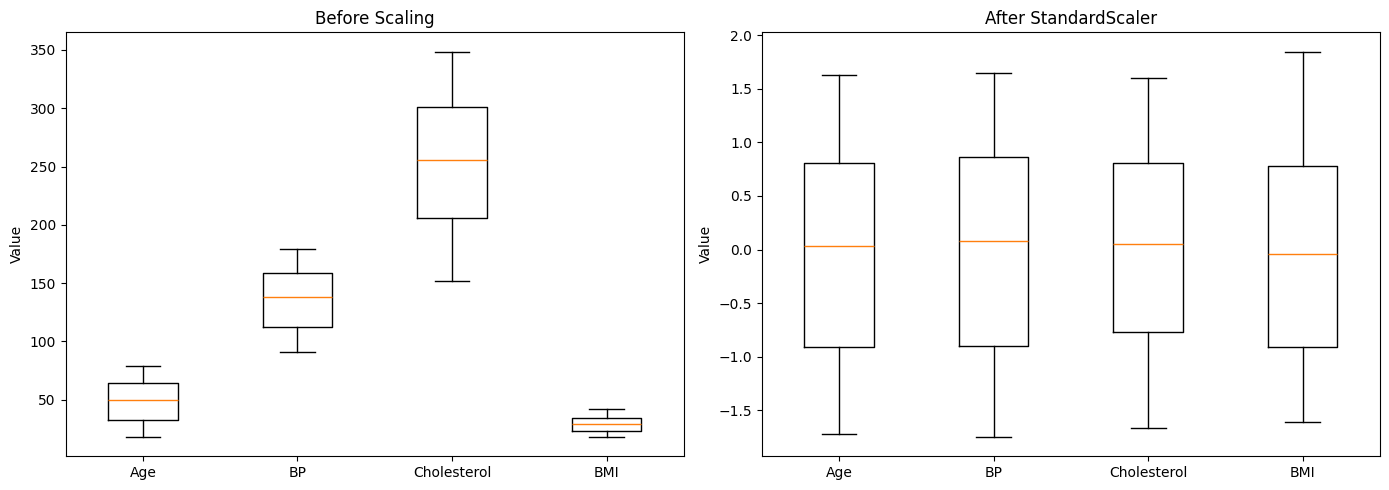

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After scaling
axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],
                 X_scaled[:, 2], X_scaled[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('After StandardScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

### Task 4: Compare Scalers

In [51]:
#apply MinMaxScaler to the same data.
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

print("Min value (should be ~0):", X_minmax.min())
print("Max value (should be ~1):", X_minmax.max())

Min value (should be ~0): 0.0
Max value (should be ~1): 1.0


**What range do the values fall into?**

*With MinMaxScaler, values fall in the range [0, 1].*

/tmp/ipython-input-3680468802.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-3680468802.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_minmax[:, 0], X_minmax[:, 1], X_minmax[:, 2], X_minmax[:, 3]],


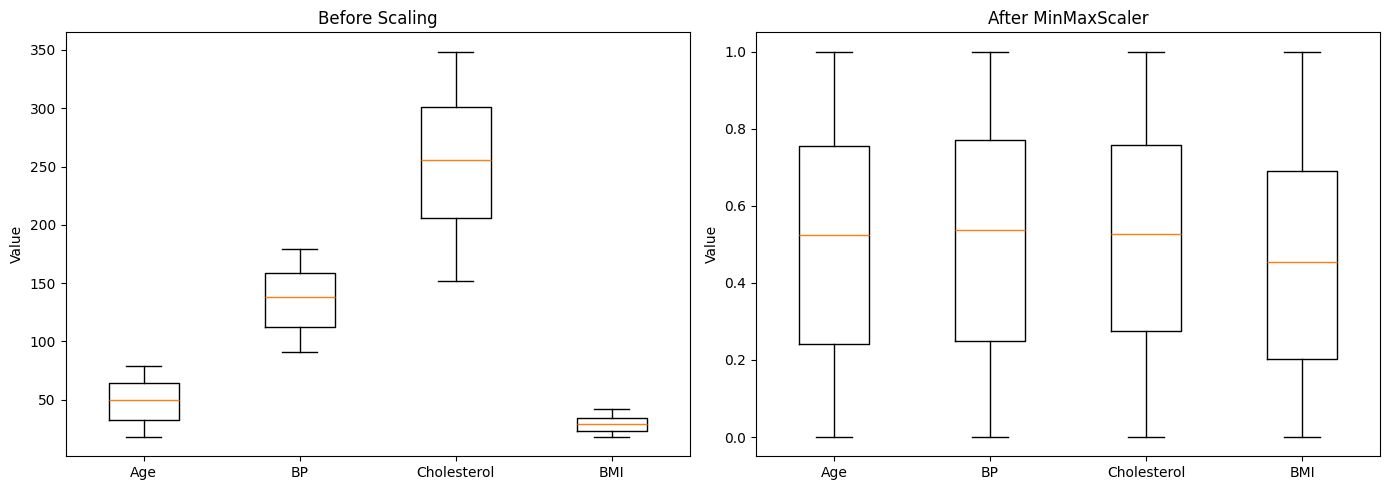

In [52]:
#create the same box plot comparison for MinMaxScaler
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

# After MinMax scaling
axes[1].boxplot([X_minmax[:, 0], X_minmax[:, 1], X_minmax[:, 2], X_minmax[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('After MinMaxScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

**How does it differ from StandardScaler?**

*After MinMaxScaler, all features are compressed into 0 to 1, so the boxplots will look much more “aligned” than before.*

**If your data has many outliers, which scaler would be more robust? Why?**

*StandardScaler is usually more robust than MinMaxScaler when you have many outliers, because MinMaxScaler uses the minimum and maximum values, so extreme outliers can stretch the scale and squeeze most values into a tiny range.*

## Part 5: The Scaling Impact – KNN Before and After

We will train KNN on the same data with and without scaling and compare the accuracy.

### 6.1 Experiment: KNN Without Scaling vs. With Scaling

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f'KNN Accuracy WITHOUT scaling: {raw_acc:.2%}')
print(f'KNN Accuracy WITH scaling: {scaled_acc:.2%}')
print(f'Improvement: {(scaled_acc - raw_acc):.2%}')

KNN Accuracy WITHOUT scaling: 67.50%
KNN Accuracy WITH scaling: 50.00%
Improvement: -17.50%


### 6.2 Bonus: Decision Tree Comparison

In [81]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt_raw.predict(X_test))

# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(X_test_s))

print(f'DT Accuracy WITHOUT scaling: {dt_raw_acc:.2%}')
print(f'DT Accuracy WITH scaling: {dt_scaled_acc:.2%}')

DT Accuracy WITHOUT scaling: 55.00%
DT Accuracy WITH scaling: 52.50%


### Task 5: Investigate Scaling Effects

In [82]:
#record the accuracy of KNN and Decision Tree with and without scaling in a table.
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "KNN (Raw)",
        "KNN (Scaled)",
        "Decision Tree (Raw)",
        "Decision Tree (Scaled)"
    ],
    "Accuracy": [
        raw_acc,
        scaled_acc,
        dt_raw_acc,
        dt_scaled_acc
    ]
})

print(results.round(4))

                    Model  Accuracy
0               KNN (Raw)     0.675
1            KNN (Scaled)     0.500
2     Decision Tree (Raw)     0.550
3  Decision Tree (Scaled)     0.525


In [83]:
#KNN with n neighbors=3 both with and without scaling.
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f'KNN Accuracy WITHOUT  (neighbors=3): {raw_acc:.2%}')
print(f'KNN Accuracy WITH scaling (neighbors=3 ): {scaled_acc:.2%}')
print(f'Improvement: {(scaled_acc - raw_acc):.2%}')

KNN Accuracy WITHOUT  (neighbors=3): 55.00%
KNN Accuracy WITH scaling (neighbors=3 ): 47.50%
Improvement: -7.50%


In [84]:
#KNN with n neighbors=10 both with and without scaling.
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- KNN WITHOUT Scaling ---
knn_raw = KNeighborsClassifier(n_neighbors=10)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

# --- KNN WITH Scaling ---
knn_scaled = KNeighborsClassifier(n_neighbors=10)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f'KNN Accuracy WITHOUT scaling (neighbors=10): {raw_acc:.2%}')
print(f'KNN Accuracy WITH scaling (neighbors=10): {scaled_acc:.2%}')
print(f'Improvement: {(scaled_acc - raw_acc):.2%}')

KNN Accuracy WITHOUT scaling (neighbors=10): 55.00%
KNN Accuracy WITH scaling (neighbors=10): 50.00%
Improvement: -5.00%


**Does scaling always help?**

*No, scaling does not always help.*

*Scaling often improves KNN performance because it balances feature influence, but it does not guarantee higher accuracy.*

*In some cases, scaling may have little effect or may even slightly reduce performance, depending on the dataset and train-test split. Therefore, scaling should be tested rather than assumed to improve results.*

**Why KNN benefits from scaling but Decision Trees do not?**

*KNN benefits from scaling because it calculates distances between data points. If features have different ranges, features with larger values dominate the distance calculation and influence the model more than smaller-scale features.*

*Scaling ensures that all features contribute more equally to the distance computation.*

*Decision Trees do not rely on distance calculations. They split the data based on feature thresholds (for example, age > 45). Since scaling does not change the order or relative comparisons of values, it does not significantly affect Decision Tree performance.*

## 7 Part 6: Building a Preprocessing Pipeline

So far we applied each step separately. In real projects, this leads to messy, error-prone code. Scikit-learn’s Pipeline chains multiple steps together into a single, clean object.

### 7.1 Why Pipelines?


**Reproducibility:** The same preprocessing is applied to training and testing data automatically.

**No data leakage:** The pipeline ensures that the scaler is fit only on training data.

**Clean code:** One object to fit, predict, and evaluate.

### 7.2 Step 1: Create a Pipeline

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Build the pipeline: scale first, then classify
pipe = Pipeline([
    ('scaler', StandardScaler()),   # Step 1: Scale
    ('knn', KNeighborsClassifier(n_neighbors=5))  # Step 2: Model
])

# Split the original (unscaled) data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# The pipeline handles scaling internally
pipe.fit(X_train, y_train)
pipe_acc = accuracy_score(y_test, pipe.predict(X_test))

print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')

Pipeline KNN Accuracy: 50.00%


### 7.3 Step 2: Swap Models Easily

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Pipeline with SVM
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

pipe_svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(X_test))

# Pipeline with Decision Tree
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

pipe_dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(X_test))

print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')
print(f'Pipeline SVM Accuracy: {svm_acc:.2%}')
print(f'Pipeline DT Accuracy: {dt_acc:.2%}')

Pipeline KNN Accuracy: 50.00%
Pipeline SVM Accuracy: 55.00%
Pipeline DT Accuracy: 52.50%


### Task 6: Build Your Own Pipeline

In [60]:
#create a pipeline that uses MinMaxScaler instead of StandardScaler with KNN.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe_minmax_knn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_minmax_knn.fit(X_train, y_train)
minmax_acc = accuracy_score(y_test, pipe_minmax_knn.predict(X_test))

print(f"Pipeline (MinMaxScaler + KNN) Accuracy: {minmax_acc:.2%}")

Pipeline (MinMaxScaler + KNN) Accuracy: 50.00%


**Compare the accuracy.**

*In this experiment, both StandardScaler and MinMaxScaler produced the same accuracy (50%). This indicates that in this dataset, the choice of scaler did not significantly affect KNN performance.*

*Since the dataset is randomly generated, there may not be strong patterns for the model to learn, resulting in similar performance across scaling methods.*

In [61]:
#add SimpleImputer as the first step in your pipeline (before the scaler)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipe_impute_scale_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_impute_scale_knn.fit(X_train, y_train)
impute_pipe_acc = accuracy_score(y_test, pipe_impute_scale_knn.predict(X_test))

print(f"Pipeline (Imputer + StandardScaler + KNN) Accuracy: {impute_pipe_acc:.2%}")

Pipeline (Imputer + StandardScaler + KNN) Accuracy: 50.00%


## 8 Part 7: Feature Selection with Correlation Analysis

Not all features are equally useful. Some may be irrelevant or redundant. Feature selection helps you identify which features actually contribute to prediction.

### 8.1 Step 1: Compute the Correlation Matrix

In [62]:
# Create a DataFrame with our processed features
df_processed = pd.DataFrame(X_scaled, columns=feature_cols)
df_processed['heart_disease'] = y

# Compute correlations
corr_matrix = df_processed.corr()

# Show correlation with the target
print('Correlation with heart_disease:')
target_corr = corr_matrix['heart_disease'].drop('heart_disease')
print(target_corr.sort_values(ascending=False).round(3))

Correlation with heart_disease:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


### 8.2 Step 2: Visualize with a Heatmap

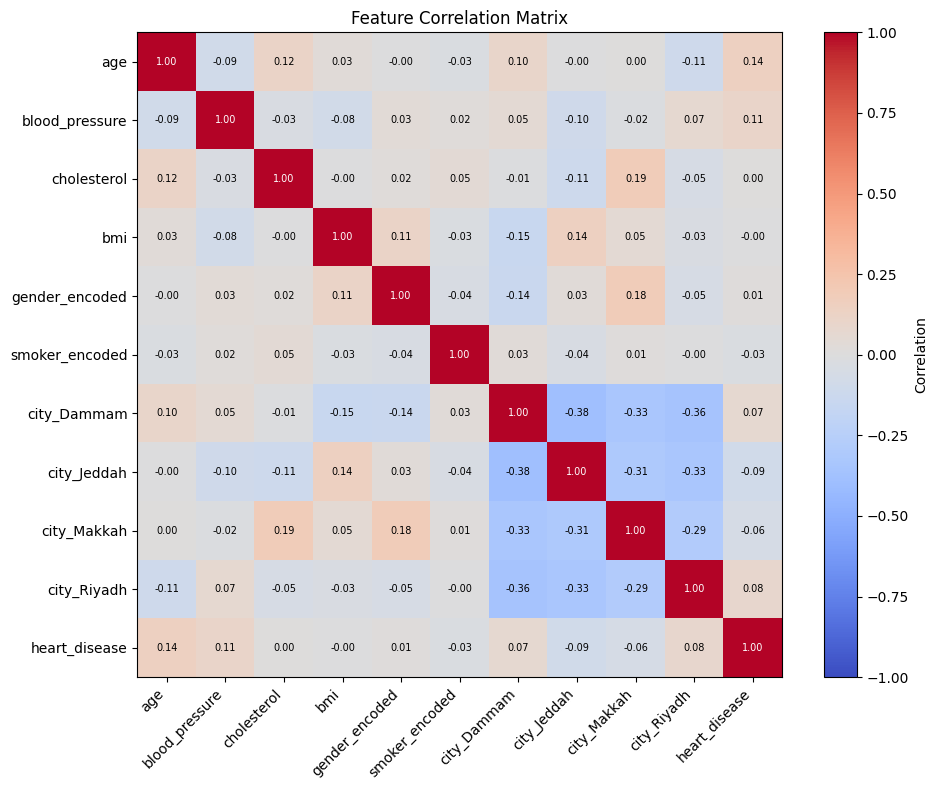

In [63]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

im = plt.imshow(corr_matrix.values,
                cmap='coolwarm',
                vmin=-1, vmax=1)

plt.colorbar(im, label='Correlation')

# Add labels
ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks, corr_matrix.columns)

# Add correlation values inside the heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}',
                 ha='center', va='center',
                 fontsize=7, color=color)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 8.3 Step 3: Select Top Features

In [64]:
# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr[abs(target_corr) > threshold]
print(f'\nFeatures with |correlation| > {threshold}:')
print(important_features.sort_values(ascending=False).round(3))

# Train with only the top features
top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print(f'\nAccuracy with ALL features: {pipe_acc:.2%}')
print(f'Accuracy with SELECTED features: {sel_acc:.2%}')
print(f'Features used: {len(top_features)} out of {len(feature_cols)}')


Features with |correlation| > 0.05:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features: 50.00%
Accuracy with SELECTED features: 55.00%
Features used: 6 out of 10


### Task 7: Feature Selection

In [89]:
target_corr.sort_values(ascending=False)

,heart_disease
age,0.142702
blood_pressure,0.106069
city_Riyadh,0.078872
city_Dammam,0.067146
gender_encoded,0.013705
cholesterol,0.002672
bmi,-0.004382
smoker_encoded,-0.025048
city_Makkah,-0.061331
city_Jeddah,-0.089100


**Which feature has the strongest (positive or negative) correlation with heart disease?**

***Strongest positive correlation:**
Age (0.143) — This suggests that as age increases, the likelihood of heart disease slightly increases.*

***Strongest negative correlation:** city_Jeddah (-0.089) — This indicates a slight negative relationship, meaning individuals from this category are slightly less associated with heart disease compared to others in the dataset.*

In [66]:
#threshold value 0.03

# Select features with absolute correlation > threshold
threshold = 0.03
important_features = target_corr[abs(target_corr) > threshold]
print(f'\nFeatures with |correlation| > {threshold}:')
print(important_features.sort_values(ascending=False).round(3))

# Train with only the top features
top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print(f'\nAccuracy with ALL features: {pipe_acc:.2%}')
print(f'Accuracy with SELECTED features: {sel_acc:.2%}')
print(f'Features used: {len(top_features)} out of {len(feature_cols)}')


Features with |correlation| > 0.03:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features: 50.00%
Accuracy with SELECTED features: 55.00%
Features used: 6 out of 10


In [67]:
#threshold value 0.08

# Select features with absolute correlation > threshold
threshold = 0.08
important_features = target_corr[abs(target_corr) > threshold]
print(f'\nFeatures with |correlation| > {threshold}:')
print(important_features.sort_values(ascending=False).round(3))

# Train with only the top features
top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print(f'\nAccuracy with ALL features: {pipe_acc:.2%}')
print(f'Accuracy with SELECTED features: {sel_acc:.2%}')
print(f'Features used: {len(top_features)} out of {len(feature_cols)}')


Features with |correlation| > 0.08:
age               0.143
blood_pressure    0.106
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features: 50.00%
Accuracy with SELECTED features: 55.00%
Features used: 3 out of 10


In [68]:
#threshold value 0.10

# Select features with absolute correlation > threshold
threshold = 0.10
important_features = target_corr[abs(target_corr) > threshold]
print(f'\nFeatures with |correlation| > {threshold}:')
print(important_features.sort_values(ascending=False).round(3))

# Train with only the top features
top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print(f'\nAccuracy with ALL features: {pipe_acc:.2%}')
print(f'Accuracy with SELECTED features: {sel_acc:.2%}')
print(f'Features used: {len(top_features)} out of {len(feature_cols)}')


Features with |correlation| > 0.1:
age               0.143
blood_pressure    0.106
Name: heart_disease, dtype: float64

Accuracy with ALL features: 50.00%
Accuracy with SELECTED features: 60.00%
Features used: 2 out of 10


**Why might using fewer features sometimes give better accuracy?**

*Using fewer features can improve accuracy because of the curse of dimensionality. When there are too many features, distances between data points become less meaningful, especially for models like KNN that rely on distance calculations.*

*By reducing the number of features, the model focuses on the most important variables, leading to clearer patterns and better performance.*

## 9 Part 8: Putting It All Together – Full Workflow

Let’s apply every technique from this lab in one clean, end-to-end workflow. This is the pattern you should follow in your own projects.

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# ===== STEP 1: Load Raw Data =====
# (Re-create the messy dataset)
np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print('=== Step 1: Raw Data ===')
print(f'Shape: {df.shape}, Missing: {df.isnull().sum().sum()}')

# ===== STEP 2: Handle Missing Values =====
num_cols = ['age', 'blood_pressure', 'cholesterol']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

print('\n=== Step 2: After Imputation ===')
print(f'Missing: {df.isnull().sum().sum()}')

# ===== STEP 3: Encode Categorical Variables =====
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoker'] = le.fit_transform(df['smoker'])

df = pd.concat([df, pd.get_dummies(df['city'], prefix='city')], axis=1)
df = df.drop(columns=['city'])

print('\n=== Step 3: After Encoding ===')
print(f'Columns: {list(df.columns)}')

# ===== STEP 4: Separate Features and Target =====
X = df.drop(columns=['heart_disease']).values
y = df['heart_disease'].values

# ===== STEP 5: Split Data =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===== STEP 6: Build Pipeline & Train =====
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipe_knn.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)

# ===== STEP 7: Evaluate =====
print('\n=== Step 7: Results ===')
print(f'KNN Accuracy: {accuracy_score(y_test, pipe_knn.predict(X_test)):.2%}')
print(f'Decision Tree Accuracy: {accuracy_score(y_test, pipe_dt.predict(X_test)):.2%}')

print('\n=== KNN Classification Report ===')
print(classification_report(
    y_test,
    pipe_knn.predict(X_test),
    target_names=['No Disease', 'Disease']
))

=== Step 1: Raw Data ===
Shape: (200, 8), Missing: 20

=== Step 2: After Imputation ===
Missing: 0

=== Step 3: After Encoding ===
Columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'gender', 'smoker', 'heart_disease', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']

=== Step 7: Results ===
KNN Accuracy: 50.00%
Decision Tree Accuracy: 52.50%

=== KNN Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.54      0.68      0.60        22
     Disease       0.42      0.28      0.33        18

    accuracy                           0.50        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.50      0.48        40



## 10 Part 9: Summary and Key Takeaways

### 10.1 The Preprocessing Workflow

**Step 1:** *Explore data* -> Understand the problems ( df.info(), df.describe() )

**Step 2:** *Handle missing values* -> Models can’t handle NaN ( SimpleImputer )

**Step 3:** *Encode categories* -> Models need numbers ( LabelEncoder, get dummies  )

**Step 4:** *Scale features* -> Equal contribution ( StandardScaler )

**Step 5:** *Select features* -> Remove noise ( Correlation analysis )

**Step 6:** *Build pipeline* -> Reproducibility ( Pipeline )

### 10.2 Key Rules to Remember

1. Always explore before preprocessing – understand what’s wrong before trying to fix it.

2. Scale for distance-based models (KNN, SVM) – tree-based models don’t need it.

3. Use One-Hot for nominal categories – Label Encoding implies false ordering.

4. Use Pipelines – they prevent data leakage and keep your code clean.

5. Fit on training data only – then transform both training and testing data.

### 10.3 What to Explore Next

- **Advanced imputation:** Try KNNImputer which uses K-Nearest Neighbors to fill missing values based on similar samples.

- **Feature engineering:** Create new features from existing ones (e.g., BMI category from BMI values).

- **ColumnTransformer:** Apply different preprocessing to different columns in a single pipeline using sklearn.compose.ColumnTransformer.

- **Cross-validation:** Use cross val score() for more robust evaluation than a single train/test split.

## 11 Submission Requirements

### 11.1 What to Submit

**Which preprocessing step had the biggest impact on model performance?**

*In this lab, feature selection had the biggest impact on model performance. When all features were used, the KNN model achieved lower accuracy, but after selecting only the most strongly correlated features, the accuracy improved.*

*Removing weak or noisy features reduced the curse of dimensionality, making distance calculations more meaningful for KNN. Since KNN relies on distances between data points, fewer relevant features helped the model focus on stronger patterns.*

*This demonstrates that eliminating unnecessary variables can significantly improve model performance.*


**Why does preprocessing matters for real-world ML projects?**

*Preprocessing is essential in real-world machine learning because raw data is often incomplete, inconsistent, or poorly formatted. Datasets may contain missing values, categorical text variables, and features with very different scales.*

*If these issues are not handled properly, the model can learn incorrect patterns or produce unreliable results.*

*Proper preprocessing ensures that features are clean, numeric, and appropriately scaled before training. It also helps prevent data leakage and improves reproducibility through pipelines. Overall, good preprocessing directly improves model accuracy, stability, and reliability in practical applications.*